# Demo Notebook para Conexão com Google Colab

Este notebook serve para:
1.  Testar a conexão com um ambiente de execução do Google Colab via VS Code.
2.  Executar comandos de shell básicos.
3.  Configurar o acesso SSH para um terminal interativo.


In [12]:
import sys

print("Olá do ambiente Colab!")
print(f"Versão do Python: {sys.version}")


Olá do ambiente Colab!
Versão do Python: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]


In [13]:
# O diretório de trabalho padrão no Colab é /content
print("--- Listando arquivos no diretório de trabalho atual ---")
!ls -la


--- Listando arquivos no diretório de trabalho atual ---
total 276
drwxr-xr-x 1 root root   4096 Apr 13 15:31 .
drwxr-xr-x 1 root root   4096 Apr 13 10:39 ..
-rw-r--r-- 1 root root   8995 Apr 13 15:30 cachorrinho.jpg
drwxr-xr-x 1 root root   4096 Apr 13 13:10 .config
-rw-r--r-- 1 root root      0 Apr 13 15:27 gatinho.jpg
-rw-r--r-- 1 root root  14919 Apr 13 15:31 imagem.jpg
drwxr-xr-x 2 root root   4096 Apr 13 13:45 .ipynb_checkpoints
-rw-r--r-- 1 root root 221433 Apr 13 13:45 MCMV.png
drwxr-xr-x 1 root root   4096 Apr  2 13:31 sample_data


### Verificando a Conta Google Autenticada no Ambiente

Podemos usar o `gcloud` CLI (Command Line Interface) para verificar qual conta Google está autenticada no ambiente de execução do Colab. Isso é útil para garantir que estamos usando a conta correta (com Colab Pro, por exemplo).

O comando `gcloud config get-value account` mostra a conta atualmente ativa.

In [14]:
# Executa o comando para verificar a conta ativa.
# Se o resultado for "(unset)", significa que nenhuma conta está autenticada para o gcloud CLI.
# Nesse caso, você precisaria abrir um terminal do Colab no VS Code e executar:
# gcloud auth login
# Depois de autenticar no terminal, execute esta célula novamente para confirmar.
!gcloud config get-value account

joao.petreche@gmail.com


### Verificando a Distribuição Linux do Ambiente

O ambiente de execução do Colab é baseado em Linux. Podemos verificar a versão específica da distribuição com o seguinte comando. Isso é útil para saber quais gerenciadores de pacotes (como `apt`) estão disponíveis.

In [15]:
# O comando `lsb_release -a` mostra informações detalhadas sobre a distribuição Linux.
# Geralmente, o Colab utiliza uma versão do Ubuntu.
!lsb_release -a

No LSB modules are available.
Distributor ID:	Ubuntu
Description:	Ubuntu 22.04.5 LTS
Release:	22.04
Codename:	jammy


### Instalação de Pacotes de Sistema (via `apt`)

Em ambientes Colab, que são baseados em Ubuntu, podemos instalar pacotes de sistema usando o gerenciador de pacotes `apt`. Isso é útil para dependências de baixo nível ou ferramentas que não são pacotes Python puros.

A célula abaixo instala a biblioteca `python3-pil`, que é a versão do sistema da biblioteca de processamento de imagens Pillow.

In [16]:
# Instala a biblioteca python3-pil no nível do sistema operacional.
# O '-y' aceita automaticamente as prompts de instalação.
!sudo apt update
!sudo apt install python3-pil -y

Hit:1 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease
Get:2 https://cli.github.com/packages stable InRelease [3,917 B]               
Get:3 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]      
Hit:4 http://archive.ubuntu.com/ubuntu jammy InRelease                         
Get:5 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]        
Hit:6 https://r2u.stat.illinois.edu/ubuntu jammy InRelease                     
Hit:7 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease   
Hit:8 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease    
Get:9 http://security.ubuntu.com/ubuntu jammy-security/universe amd64 Packages [1,311 kB]
Hit:10 http://archive.ubuntu.com/ubuntu jammy-backports InReleasem
Get:11 http://archive.ubuntu.com/ubuntu jammy-updates/main amd64 Packages [4,226 kB]
Get:12 http://security.ubuntu.com/ubuntu jammy-security/main amd64 Packages [3,895 kB]3m
Fetched 9,693 kB in 3s (3,177 kB/s

### Manipulando e Exibindo Imagens no VS Code

O ambiente Colab vem com bibliotecas de manipulação de imagem pré-instaladas, como a `Pillow` (sucessora da PIL). Para exibir uma imagem diretamente na saída da célula, podemos usar a biblioteca `IPython.display`.

**Para usar arquivos (como imagens) no VS Code com a extensão Colab:**

1.  **Upload:** Simplesmente arraste e solte o arquivo do seu computador para a pasta `/content` no painel "Explorer" do VS Code.
2.  **Download:** Clique com o botão direito no arquivo no painel "Explorer" e selecione "Download".


-rw-r--r-- 1 root root 221433 Apr 13 13:45 /content/MCMV.png
Imagem 'MCMV.png' carregada com sucesso!
Formato: PNG, Dimensões: (793, 557), Modo: RGBA


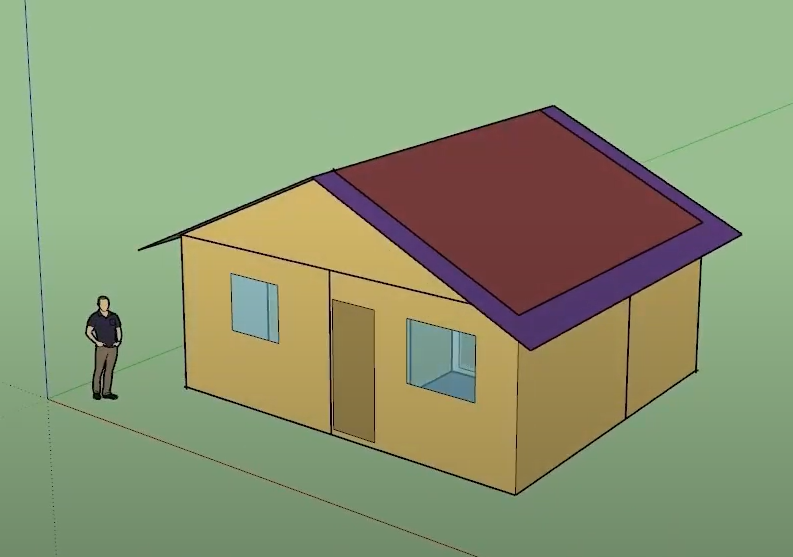

In [19]:
# Exemplo de como abrir e inspecionar uma imagem (ex: 'MCMV.png')
# E exibi-la diretamente na saída da célula.
from PIL import Image
from IPython.display import display
import os

# Faça upload da imagem 'MCMV.png' para o diretório de trabalho do Colab (/content/), clicando com o botão direito e selecionando "Upload to Colab"
image_path = '/content/MCMV.png'

!ls -la /content/MCMV.png  # Verifica se o arquivo foi carregado corretamente

if os.path.exists(image_path):
    try:
        img = Image.open(image_path)
        print(f"Imagem '{os.path.basename(image_path)}' carregada com sucesso!")
        print(f"Formato: {img.format}, Dimensões: {img.size}, Modo: {img.mode}")
        display(img) # Exibe a imagem na saída da célula
    except Exception as e:
        print(f"Ocorreu um erro ao abrir a imagem: {e}")
else:
    print(f"Erro: A imagem '{image_path}' não foi encontrada.")
    print("Por favor, arraste e solte o arquivo 'MCMV.png' para a pasta '/content' no explorador de arquivos do VS Code.")

### Carregando uma Imagem Programaticamente (via URL)

A maneira mais comum e reprodutível de carregar uma imagem em um notebook é baixá-la de uma URL usando o comando de shell `wget`. Isso garante que qualquer pessoa que execute o notebook terá o mesmo arquivo.

A célula abaixo baixa uma imagem de exemplo e a exibe.

--2026-04-13 15:32:39--  https://picsum.photos/200/300
Resolving picsum.photos (picsum.photos)... 172.67.74.163, 104.26.4.30, 104.26.5.30, ...
Connecting to picsum.photos (picsum.photos)|172.67.74.163|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://fastly.picsum.photos/id/846/200/300.jpg?hmac=56qbTJ7KrbbWoe5OYb__qtZZt0ydzvJU0sFHaEsDUS0 [following]
--2026-04-13 15:32:40--  https://fastly.picsum.photos/id/846/200/300.jpg?hmac=56qbTJ7KrbbWoe5OYb__qtZZt0ydzvJU0sFHaEsDUS0
Resolving fastly.picsum.photos (fastly.picsum.photos)... 151.101.1.91, 151.101.65.91, 151.101.129.91, ...
Connecting to fastly.picsum.photos (fastly.picsum.photos)|151.101.1.91|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 16156 (16K) [image/jpeg]
Saving to: ‘imagem.jpg’

imagem.jpg          100%[===================>]  15.78K  --.-KB/s    in 0.001s  

2026-04-13 15:32:40 (13.4 MB/s) - ‘imagem.jpg’ saved [16156/16156]



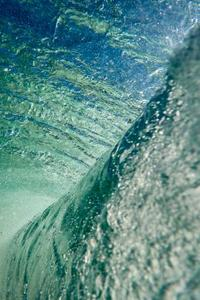

In [18]:
# O comando !wget baixa um arquivo de uma URL.
# A opção -O (letra O maiúscula) permite especificar o nome do arquivo de saída.
!wget https://picsum.photos/200/300 -O imagem.jpg

# Agora, vamos exibir a imagem que acabamos de baixar:
display(Image.open('imagem.jpg'))

In [1]:
!sudo apt install python3-pip -y

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following additional packages will be installed:
  javascript-common libjs-sphinxdoc libjs-underscore python3-dev
  python3-pkg-resources python3-setuptools python3-wheel python3.10-dev
Suggested packages:
  apache2 | lighttpd | httpd python-setuptools-doc
The following NEW packages will be installed:
  javascript-common libjs-sphinxdoc libjs-underscore python3-dev python3-pip
  python3-setuptools python3-wheel python3.10-dev
The following packages will be upgraded:
  python3-pkg-resources
1 upgraded, 8 newly installed, 0 to remove and 23 not upgraded.
Need to get 2,816 kB of archives.
After this operation, 10.9 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/main amd64 javascript-common all 11+nmu1 [5,936 B]
Get:2 http://archive.ubuntu.com/ubuntu jammy/main amd64 libjs-underscore all 1.13.2~dfsg-2 [118 kB]
Get:3 https://ppa.launchpadcontent.net/ub

In [2]:
! pip3 install pandas

In [3]:
import pandas as pd

In [12]:
data={'Name': ['Alice', 'Bob', 'Charlie'],
    'Age': [25, 30, 35]
}
print(type(data))
visitors = pd.DataFrame(data, index=['Visitor1', 'Visitor2', 'Visitor3'])
print(visitors)

<class 'dict'>
             Name  Age
Visitor1    Alice   25
Visitor2      Bob   30
Visitor3  Charlie   35
